In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys

In [3]:
from analysis_tools.workflows.evaluation_flow import evaluation_flow, evaluation_flow_zheyang
from analysis_tools.workflows.BDT_pipeline import run_bdt_pipeline
from analysis_tools.namings.BDT_feature_naming import BDT_feature_name_change
from analysis_tools.BDT_tools.Testset_preparation import create_learning_input,annotate_labels, annotate_labels_zheyang
from analysis_tools.BDT_tools.BDT_evaluation import find_best_two_bdt_thresholds,plot_bdt_threshold_scan
from analysis_tools.workflows.prediction_flow import prediction_flow,predict_scores
from analysis_tools.my_selectors.apply_selection import apply_selection

/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
output_dir = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/notebooks/retrain_zheyang/compare_datasets"
os.system(f"mkdir -p {output_dir}")

0

First compare zheyangs training and evaluation hdfs. They are not his NNMFit files. Interesting variables are
- cscdSBU_MCPrimary_energy
- cscdSBU_MonopodFit4_noDC_energy
- I3MCWeightDict_PrimaryNeutrinoType
- astro_weight, conv_weight, prompt_weight, weight. 

weight is the sum of astro, conv and prompt. But it seems like a yearly rate?

After talking to Zheyang
- Where these files used for training? 
- They have a energy cut of log10(cscdSBU_MonopodFit4_noDC_energy) > 4.5
- for livetime year he uses: livetime = 1*365*24*3600
- astro weight is defined in: /data/user/zchen/analysis_tools/analysis_tools/data_process/utils/pass2_weight/calculate_weight.py, using gamma 2.58 and norm 1.83

df['astro_weight'] = astro_norm * 1.e-18 * df['I3MCWeightDict_OneWeight'] / (df['I3MCWeightDict_NEvents'] * nfiles) * np.power(df['I3MCWeightDict_PrimaryNeutrinoEnergy']/1.e5, astro_index)* ltime


In [5]:
df_22612_22645 = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22612-22645.h5")
df_22684_22692 = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22684-22692.h5")

In [8]:
Taupede_name = 'Taupede_ftp'
precut_dict = {'cscdSBU_MonopodFit4_noDC_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_value':('>', 10**3),
                  f'{Taupede_name}_Distance_value':[('>', 10),('<', 400)],
                  'cscdSBU_LE_bdt_input_cscdSBU_I3XYScale_noDC_value':('<', 0.9),
                  'cscdSBU_MonopodFit4_noDC_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_1Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_2Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_22612_22645_precut = apply_selection(df_22612_22645,precut_dict).copy()
df_22684_22692_precut = apply_selection(df_22684_22692,precut_dict).copy()

In [9]:
def compare_energy_distributions_multi(
    dfs,
    labels,
    energy_vars,
    primary_vars,
    weight_vars,
    bins=np.geomspace(10**4.5, 10**7.0, 14),
    xlabel = "PrimaryNeutrinoEnergy [GeV]",
    cut_query=None,
    yscale="linear",
):

    flavors = [("NuE", 12), ("NuMu", 14), ("NuTau", 16)]

    if cut_query is not None:
        dfs = [df.query(cut_query) for df in dfs]

    n_datasets = len(dfs)

    fig, axs = plt.subplots(
        2,
        3,
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(12, 6),
    )

    for col, (flav_label, pid) in enumerate(flavors):

        histograms = []
        legend_entries = []
        lines = []

        for i in range(n_datasets):

            df = dfs[i]
            evar = energy_vars[i]
            pvar = primary_vars[i]
            wvar = weight_vars[i]

            mask = abs(df[pvar]) == pid

            E = df.loc[mask, evar]
            w = df.loc[mask, wvar]

            h, _ = np.histogram(E, bins=bins, weights=w)
            err = np.sqrt(np.histogram(E, bins=bins, weights=w**2)[0])

            histograms.append(h)

            line = axs[0, col].step(
                bins[:-1],
                h,
                where="post",
                label=labels[i],
            )[0]

            lines.append(line)

            axs[0, col].fill_between(
                bins[:-1],
                h - err,
                h + err,
                step="post",
                alpha=0.2,
            )

            # summed rate
            rate = w.sum()
            rate_err = np.sqrt((w**2).sum())

            legend_entries.append(
                f"{labels[i]} : {rate:.3f} ± {rate_err:.3f} /yr"
            )

        # ratio relative to first dataset
        h_ref = histograms[0]

        for i in range(1, n_datasets):

            ratio = np.divide(histograms[i], h_ref, where=h_ref > 0)

            axs[1, col].step(
                bins[:-1],
                ratio,
                where="post",
                linestyle="--",
            )

        axs[1, col].axhline(1, color="black")

        axs[0, col].set_title(flav_label)

        # legend for this flavor
        axs[0, col].legend(lines,legend_entries, fontsize=9)

    # axis formatting
    for ax in axs[0]:
        ax.set_xscale("log")
        ax.set_yscale(yscale)

    for ax in axs[1]:
        ax.set_xscale("log")
        ax.set_ylim(0, 2)

    axs[0, 0].set_ylabel("Rate / year")
    axs[1, 0].set_ylabel("Ratio")

    for ax in axs[1]:
        ax.set_xlabel(xlabel)

    plt.tight_layout()

    # return fig, axs

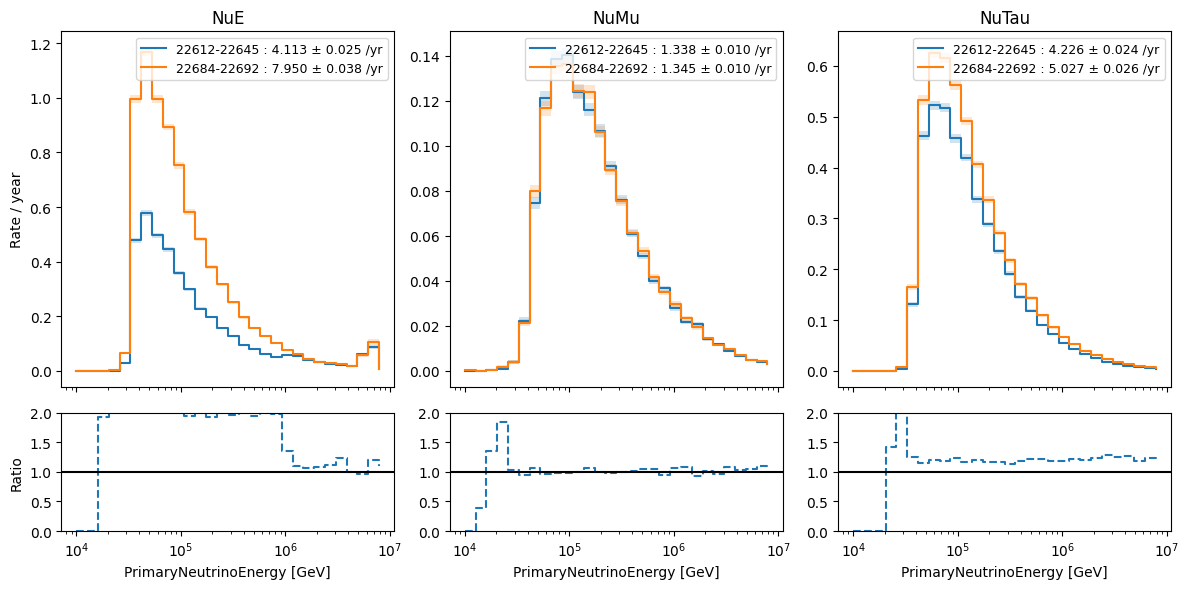

In [26]:
compare_energy_distributions_multi(
    [df_22612_22645,df_22684_22692],
    ["22612-22645","22684-22692"],
    ["cscdSBU_MCPrimary_energy", "cscdSBU_MCPrimary_energy"],
    ["I3MCWeightDict_PrimaryNeutrinoType", "I3MCWeightDict_PrimaryNeutrinoType"],
    ["astro_weight","astro_weight"],
    bins=np.geomspace(10**4, 10**7.0, 30),
    cut_query=None,
    xlabel = "PrimaryNeutrinoEnergy [GeV]",
    yscale="linear",
)

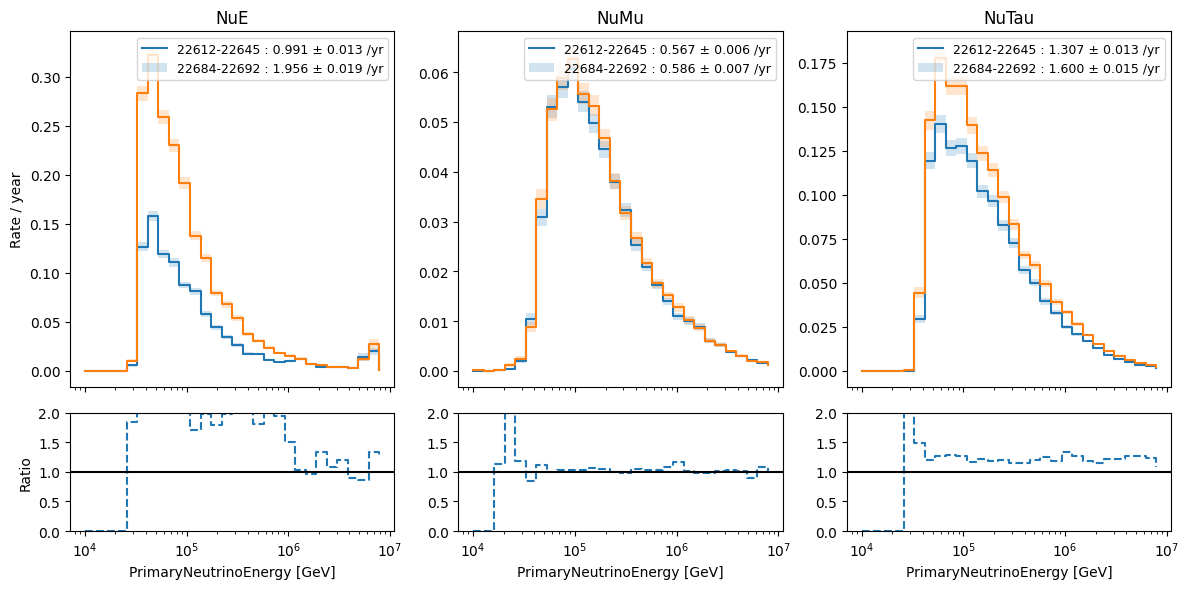

In [12]:
compare_energy_distributions_multi(
    [df_22612_22645_precut,df_22684_22692_precut],
    ["22612-22645","22684-22692"],
    ["cscdSBU_MCPrimary_energy", "cscdSBU_MCPrimary_energy"],
    ["I3MCWeightDict_PrimaryNeutrinoType", "I3MCWeightDict_PrimaryNeutrinoType"],
    ["astro_weight","astro_weight"],
    bins=np.geomspace(10**4, 10**7.0, 30),
    cut_query=None,
    xlabel = "PrimaryNeutrinoEnergy [GeV]",
    yscale="linear",
)

So in between Zheyangs training/evaluation files there are significant differences in rates for weight, astro_weight, with and without precuts. I am now trying to figure out with him what the difference is.

Now lets look at my NNMFit file and zheyangs nnmfit file.

# Zheyang nnm
- energy_monopod
- MCPrimaryType
- MCPrimaryEnergy
- fluxless_weight

# My file
- MCPrimaryEnergy
- energy_monopod
- MonopodFit_iMIGRAD_PPB0_energy
- MCPrimaryType
- fluxless_weight

In [10]:
df_22684_22692_nnm = pd.read_hdf("/data/user/zchen/Fittings/analysis/ftp_v3_withreco/datasets/baseline/snowstorm_cascade/dataset_cascade_baseline.hdf")

In [13]:
def append_astro_weight( df, per_flavor_norm = 1.83, gamma_astro = 2.58, livetime = 1*365*24*3600 ):
    norm_factor = 0.5 * per_flavor_norm * 1e-18
    e = df["MCPrimaryEnergy"] / 1e5
    df["astro_weight"] = df["fluxless_weight"] * norm_factor * e**(-gamma_astro)*livetime
    return df

In [11]:
datasets_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/GP_globalfit/combined/SnowStorm_FTP_cscd_cascade/"
df_22612_22645_thijs_all = pd.read_parquet(f"{datasets_path}/dataset_IC86_pass2_SnowStorm_FTP_cscd_cascade_baseline.parquet")

datasets_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/GP_globalfit/combined/SnowStorm_FTP_cscd_cascade_taureco/"
df_22612_22645_thijs_taureco = pd.read_parquet(f"{datasets_path}/dataset_IC86_pass2_SnowStorm_FTP_cscd_cascade_taureco_baseline.parquet")

In [16]:
df_22684_22692_nnm = append_astro_weight(df_22684_22692_nnm)
df_22612_22645_thijs_all = append_astro_weight(df_22612_22645_thijs_all)
df_22612_22645_thijs_taureco = append_astro_weight(df_22612_22645_thijs_taureco)

In [17]:
Taupede_name = 'TaupedeFit_iMIGRAD_PPB0'
cut_criteria_thijs = {'MonopodFit_iMIGRAD_PPB0_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_log':('>', 3),
                  f'Taupede_Distance':[('>', 10),('<', 400)],
                  'L4_LE_monopod_xyscale':('<', 0.9), # L4_LE_monopod_xyscale cscdSBU_I3XYScale_noDC
                  'L4_LE_monopod_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_1_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_2_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_22612_22645_thijs_taureco_precut = apply_selection(df_22612_22645_thijs_taureco,cut_criteria_thijs)

In [18]:
Taupede_name = 'TaupedeFit_iMIGRAD_PPB0'
cut_criteria_nnm = {'energy_monopod':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_log_value':('>', 3),
                  f'Taupede_Distance_value':[('>', 10),('<', 400)],
                  'cscdSBU_I3XYScale_noDC_value':('<', 0.9), # L4_LE_monopod_xyscale cscdSBU_I3XYScale_noDC
                  'cscdSBU_MonopodFit4_noDC_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'Taupede_1Particles_z':[('>', -500),('<', 500)],
                  f'Taupede_1Particles_y':[('>', -500),('<', 500)],
                  f'Taupede_1Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'Taupede_2Particles_x':[('>', -500),('<', 500)],
                  f'Taupede_2Particles_y':[('>', -500),('<', 500)],
                  f'Taupede_2Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_22684_22692_nnm_precut = apply_selection(df_22684_22692_nnm,cut_criteria_nnm)

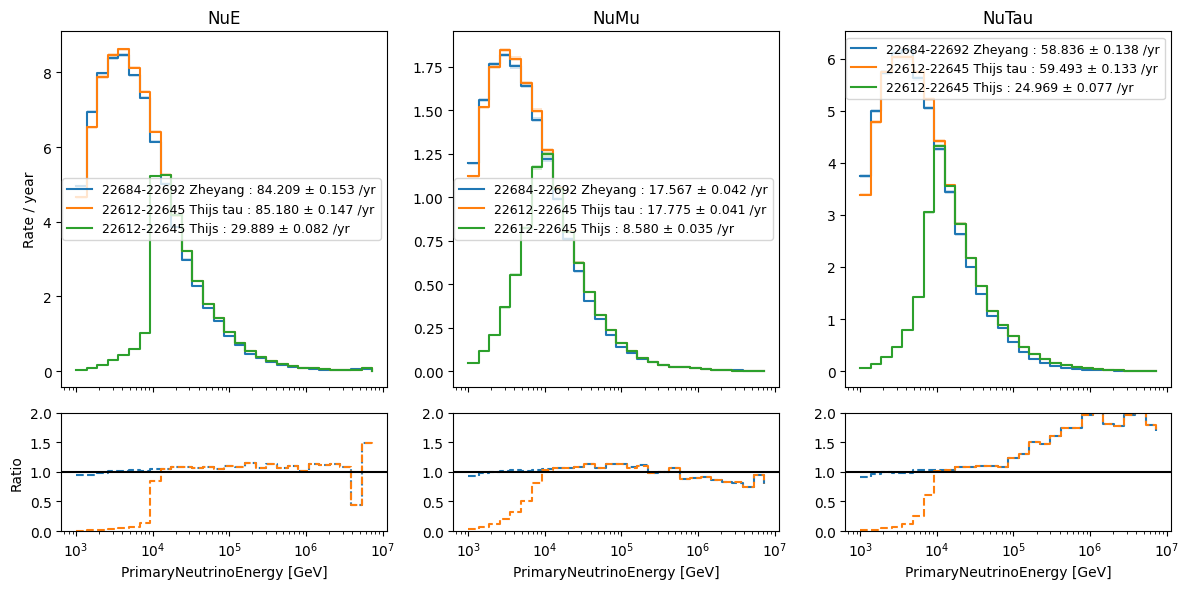

In [21]:
compare_energy_distributions_multi(
    [df_22684_22692_nnm,df_22612_22645_thijs_all,df_22612_22645_thijs_taureco],
    ["22684-22692 Zheyang","22612-22645 Thijs tau","22612-22645 Thijs"],
    ["energy_monopod", "energy_monopod", "energy_monopod"],
    ["MCPrimaryType", "MCPrimaryType", "MCPrimaryType"],
    ["astro_weight","astro_weight","astro_weight"],
    bins=np.geomspace(10**3, 10**7.0, 30),
    cut_query=None,
    xlabel = "PrimaryNeutrinoEnergy [GeV]",
    yscale="linear",
)

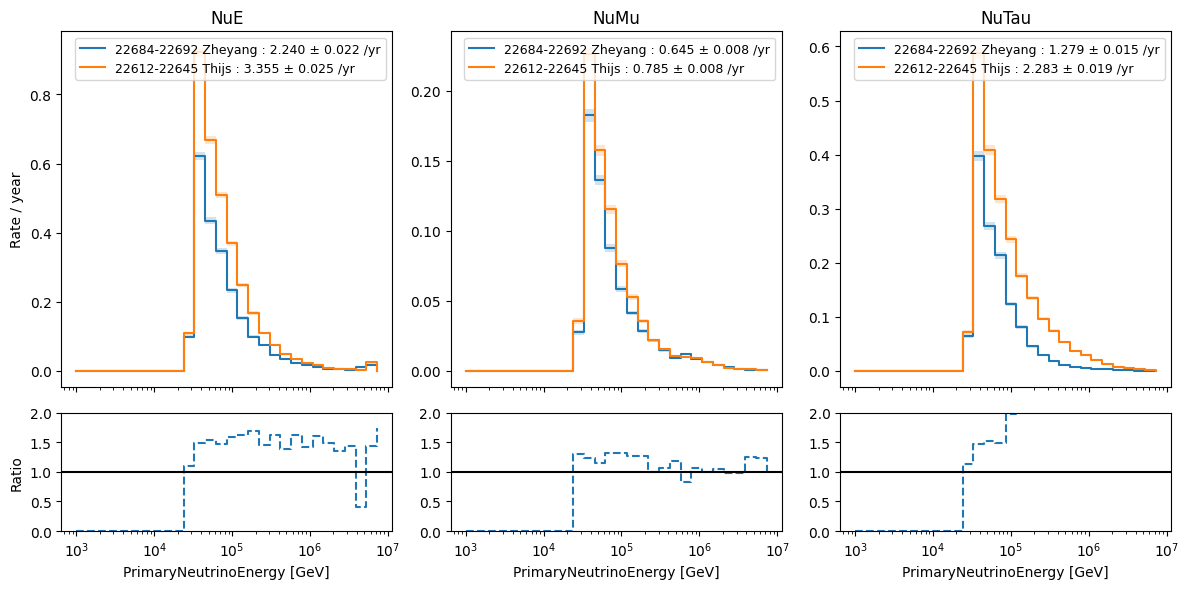

In [20]:
compare_energy_distributions_multi(
    [df_22684_22692_nnm_precut,df_22612_22645_thijs_taureco_precut],
    ["22684-22692 Zheyang","22612-22645 Thijs"],
    ["energy_monopod", "energy_monopod"],
    ["MCPrimaryType", "MCPrimaryType"],
    ["astro_weight","astro_weight"],
    bins=np.geomspace(10**3, 10**7.0, 30),
    cut_query=None,
    xlabel = "PrimaryNeutrinoEnergy [GeV]",
    yscale="linear",
)

Lets apply zheyangs bdt

In [22]:
import pickle
model_path = "/data/user/zchen/unblinding/BDT_results/models"
with open(f'{model_path}/bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(f'{model_path}/bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.45, 'bdt2_score': 0.67}

/tmp/ipykernel_1357096/1041714704.py:4: UserWarning: [03:05:20] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  bdt1 = pickle.load(f)


In [26]:
features_list = ['TauMonoDiff_rlogl_value',
                'Taupede_Asymmetry_value',
                'Taupede_Distance_value',
                'Taupede_1Particles_energy',
                'Taupede_2Particles_energy',
                'cscdSBU_MonopodFit4_noDC_zenith',
                'cscdSBU_MonopodFit4_noDC_Delay_ice_value',
                'CVStatistics_q_max_doms',
                'cscdSBU_VertexRecoDist_CscdLLh',
                'energy_monopod',
                'cscdSBU_Qtot_HLC_log_value']

In [27]:
df_22684_22692_nnm_scores = prediction_flow(
    df_22684_22692_nnm_precut,
    models,
    features_list,
    thresholds=thresholds
)

In [30]:
features_list = ['TauMonoDiff_rlogl',
                'Taupede_Asymmetry',
                'Taupede_Distance',
                'Taupede1_Particles_energy',
                'Taupede2_Particles_energy',
                'cscdSBU_MonopodFit4_noDC_zenith',
                'MonopodFit_iMIGRAD_PPB0_Delay_ice',
                'CVStatistics_q_max_doms',
                'cscdSBU_VertexRecoDist_CscdLLh',
                'energy_monopod',
                'cscdSBU_Qtot_HLC_log']

In [31]:
df_22612_22645_thijs_taureco_scores = prediction_flow(
    df_22612_22645_thijs_taureco_precut,
    models,
    features_list,
    thresholds=thresholds
)

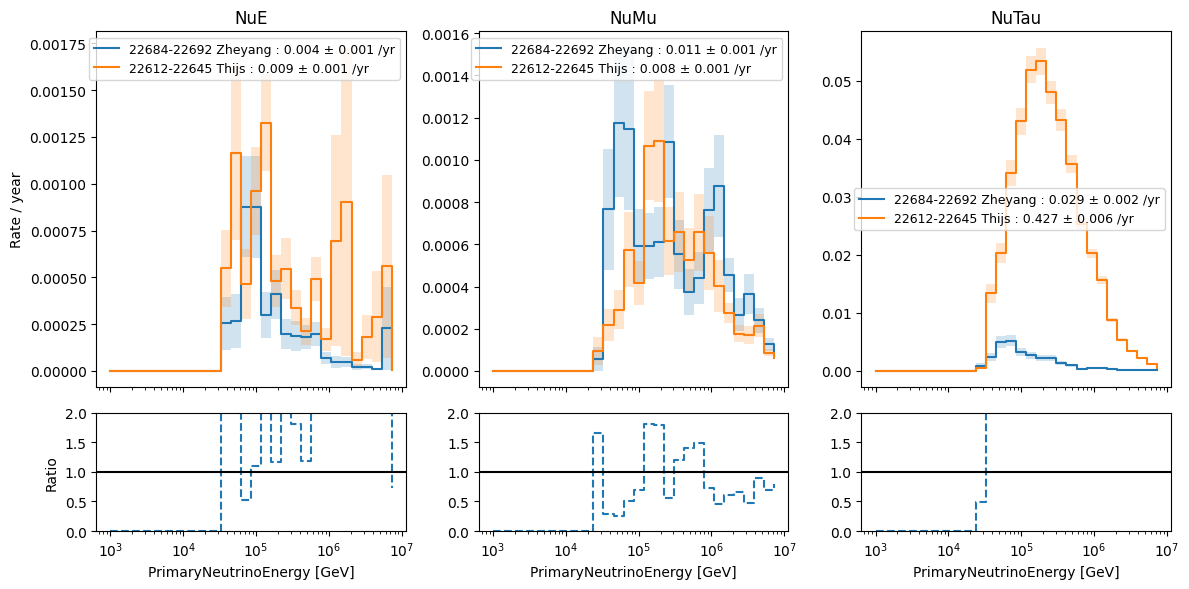

In [32]:
    

compare_energy_distributions_multi(
    [df_22684_22692_nnm_scores,df_22612_22645_thijs_taureco_scores],
    ["22684-22692 Zheyang","22612-22645 Thijs"],
    ["energy_monopod", "energy_monopod"],
    ["MCPrimaryType", "MCPrimaryType"],
    ["astro_weight","astro_weight"],
    bins=np.geomspace(10**3, 10**7.0, 30),
    cut_query="bdt1_score > 0.45 and bdt2_score > 0.67",
    xlabel = "PrimaryNeutrinoEnergy [GeV]",
    yscale="linear",
)